<a href="https://colab.research.google.com/github/aathil28/Assesment/blob/main/Superviced_learning_Athil_Thaha_13_July.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing Libraries

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

In [83]:
filepath = '/content/drive/MyDrive/Datasets/heart_disease.csv'
df_heart_disease = pd.read_csv(filepath)
df_heart_disease.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


#EDA

In [84]:
df_heart_disease.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [85]:
df_heart_disease.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [86]:
df_heart_disease.shape

(1025, 14)

In [87]:
df_heart_disease.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [88]:
df_heart_disease.isna()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1021,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1022,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1023,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [89]:
df_heart_disease.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [90]:
df_heart_disease.duplicated() # Before duplicates removal

,0
0,False
1,False
2,False
3,False
4,False
...,...
1020,True
1021,True
1022,True
1023,True


In [91]:
df_heart_disease.drop_duplicates(inplace=True)

In [92]:
df_heart_disease.duplicated() # After duplicates removal

,0
0,False
1,False
2,False
3,False
4,False
...,...
723,False
733,False
739,False
843,False


In [93]:
for i in df_heart_disease.columns:
  print('Columns :',i)
  print(df_heart_disease[i].unique())

Columns : age
[52 53 70 61 62 58 55 46 54 71 43 34 51 50 60 67 45 63 42 44 56 57 59 64
 65 41 66 38 49 48 29 37 47 68 76 40 39 77 69 35 74]
Columns : sex
[1 0]
Columns : cp
[0 1 2 3]
Columns : trestbps
[125 140 145 148 138 100 114 160 120 122 112 132 118 128 124 106 104 135
 130 136 180 129 150 178 146 117 152 154 170 134 174 144 108 123 110 142
 126 192 115  94 200 165 102 105 155 172 164 156 101]
Columns : chol
[212 203 174 294 248 318 289 249 286 149 341 210 298 204 308 266 244 211
 185 223 208 252 209 307 233 319 256 327 169 131 269 196 231 213 271 263
 229 360 258 330 342 226 228 278 230 283 241 175 188 217 193 245 232 299
 288 197 315 215 164 326 207 177 257 255 187 201 220 268 267 236 303 282
 126 309 186 275 281 206 335 218 254 295 417 260 240 302 192 225 325 235
 274 234 182 167 172 321 300 199 564 157 304 222 184 354 160 247 239 246
 409 293 180 250 221 200 227 243 311 261 242 205 306 219 353 198 394 183
 237 224 265 313 340 259 270 216 264 276 322 214 273 253 176 284 305 168

In [94]:
for i in df_heart_disease.columns:
  print('Columns :',i)
  print(df_heart_disease[i].value_counts())

Columns : age
age
58    19
57    17
54    16
59    14
52    13
51    12
60    11
62    11
44    11
56    11
64    10
41    10
63     9
67     9
53     8
61     8
55     8
65     8
45     8
42     8
43     8
48     7
46     7
66     7
50     7
47     5
49     5
70     4
35     4
39     4
68     4
69     3
71     3
40     3
34     2
38     2
37     2
29     1
76     1
77     1
74     1
Name: count, dtype: int64
Columns : sex
sex
1    206
0     96
Name: count, dtype: int64
Columns : cp
cp
0    143
2     86
1     50
3     23
Name: count, dtype: int64
Columns : trestbps
trestbps
120    37
130    36
140    32
110    19
150    17
128    12
138    12
160    11
125    11
112     9
132     8
118     7
124     6
135     6
108     6
152     5
145     5
134     5
100     4
122     4
170     4
180     3
126     3
142     3
105     3
115     3
136     3
102     2
148     2
146     2
94      2
178     2
144     2
104     1
106     1
114     1
129     1
174     1
154     1
117     1
123     1
200     1

#Outlier Handling

In [95]:

num_cols = df_heart_disease.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_heart_disease.select_dtypes(include=['object', 'bool']).columns


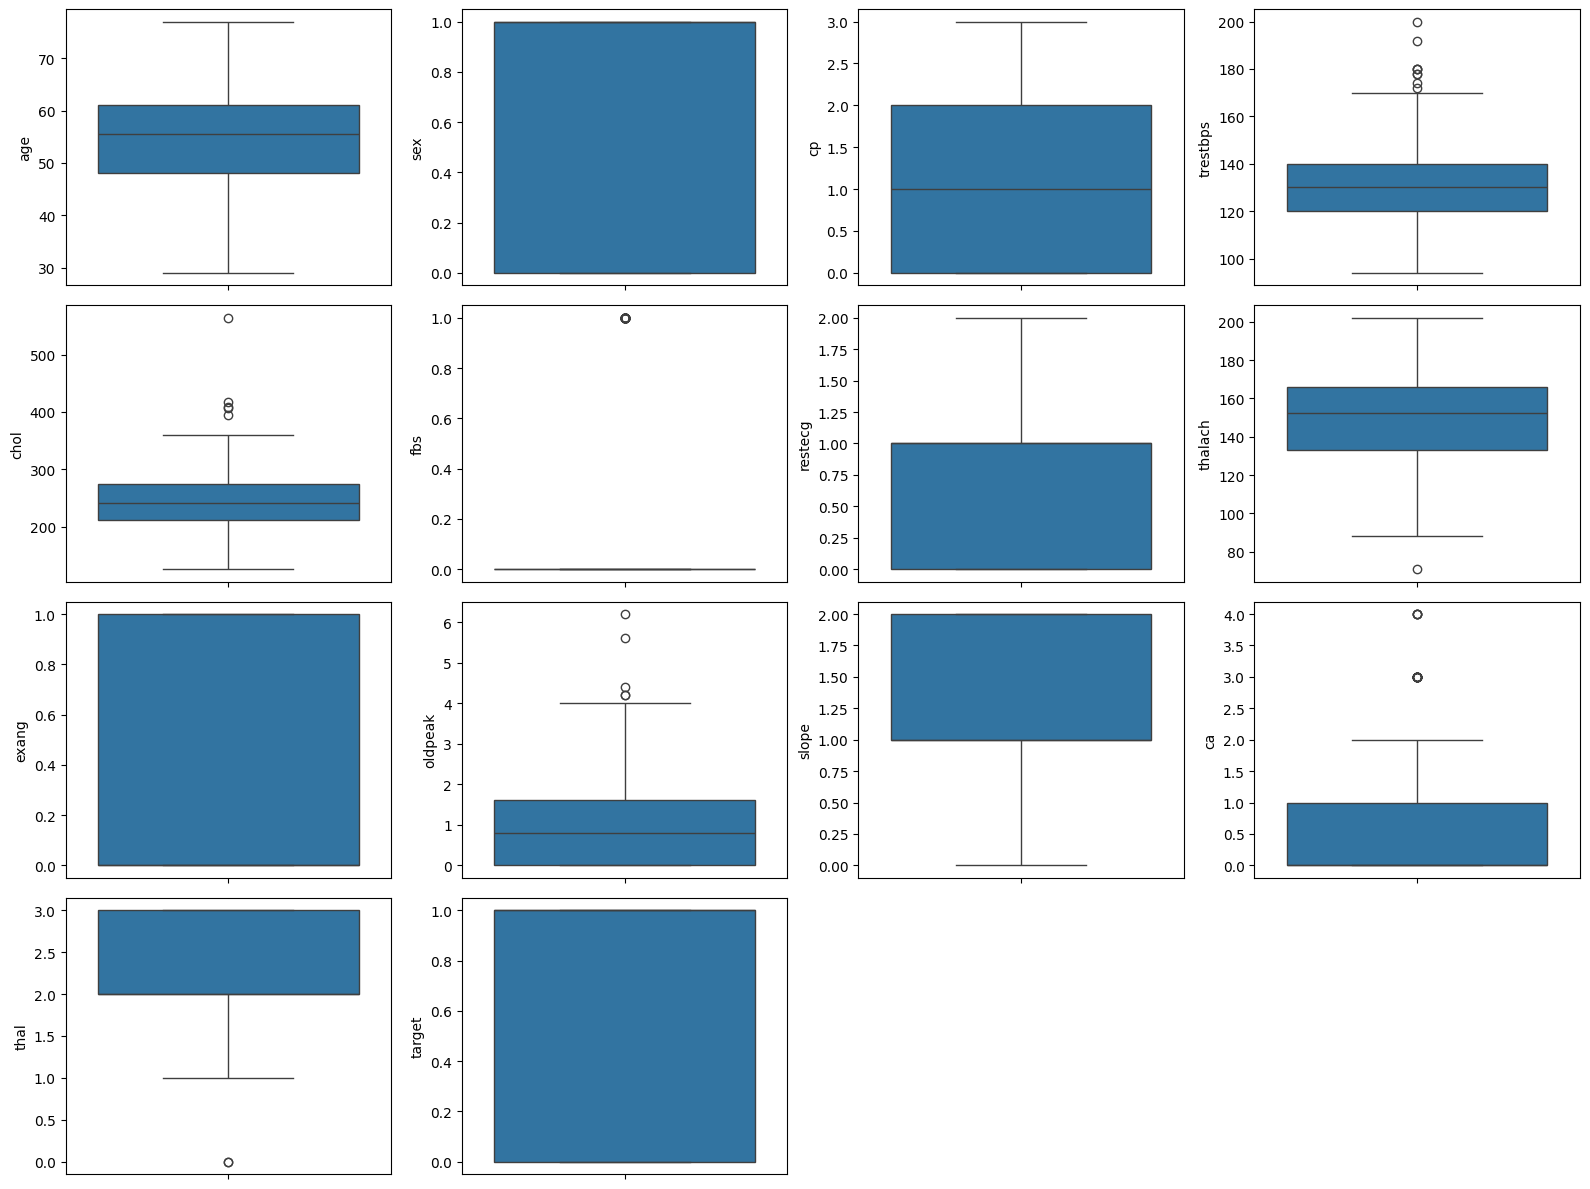

In [96]:
# Before outlier handling
plt.figure(figsize=(16,12))
for i in range(len(num_cols)):
  plt.subplot(4, 4, i+1)
  sns.boxplot(df_heart_disease[num_cols[i]])
plt.tight_layout()
plt.show()

In [97]:
# Continuous columns only
continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# Store thresholds for reference
outlier_bounds = {}

for col in continuous_cols:
    q1 = df_heart_disease[col].quantile(0.25)
    q3 = df_heart_disease[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR

    outlier_bounds[col] = {"lower": lower, "upper": upper}

    # Cap values instead of deleting rows
    df_heart_disease[col] = df_heart_disease[col].clip(lower=lower, upper=upper)

print(outlier_bounds)

{'age': {'lower': np.float64(46.5), 'upper': np.float64(62.5)}, 'trestbps': {'lower': np.float64(118.5), 'upper': np.float64(141.5)}, 'chol': {'lower': np.float64(209.5), 'upper': np.float64(276.25)}, 'thalach': {'lower': np.float64(131.75), 'upper': np.float64(167.5)}, 'oldpeak': {'lower': np.float64(-1.5), 'upper': np.float64(3.1)}}


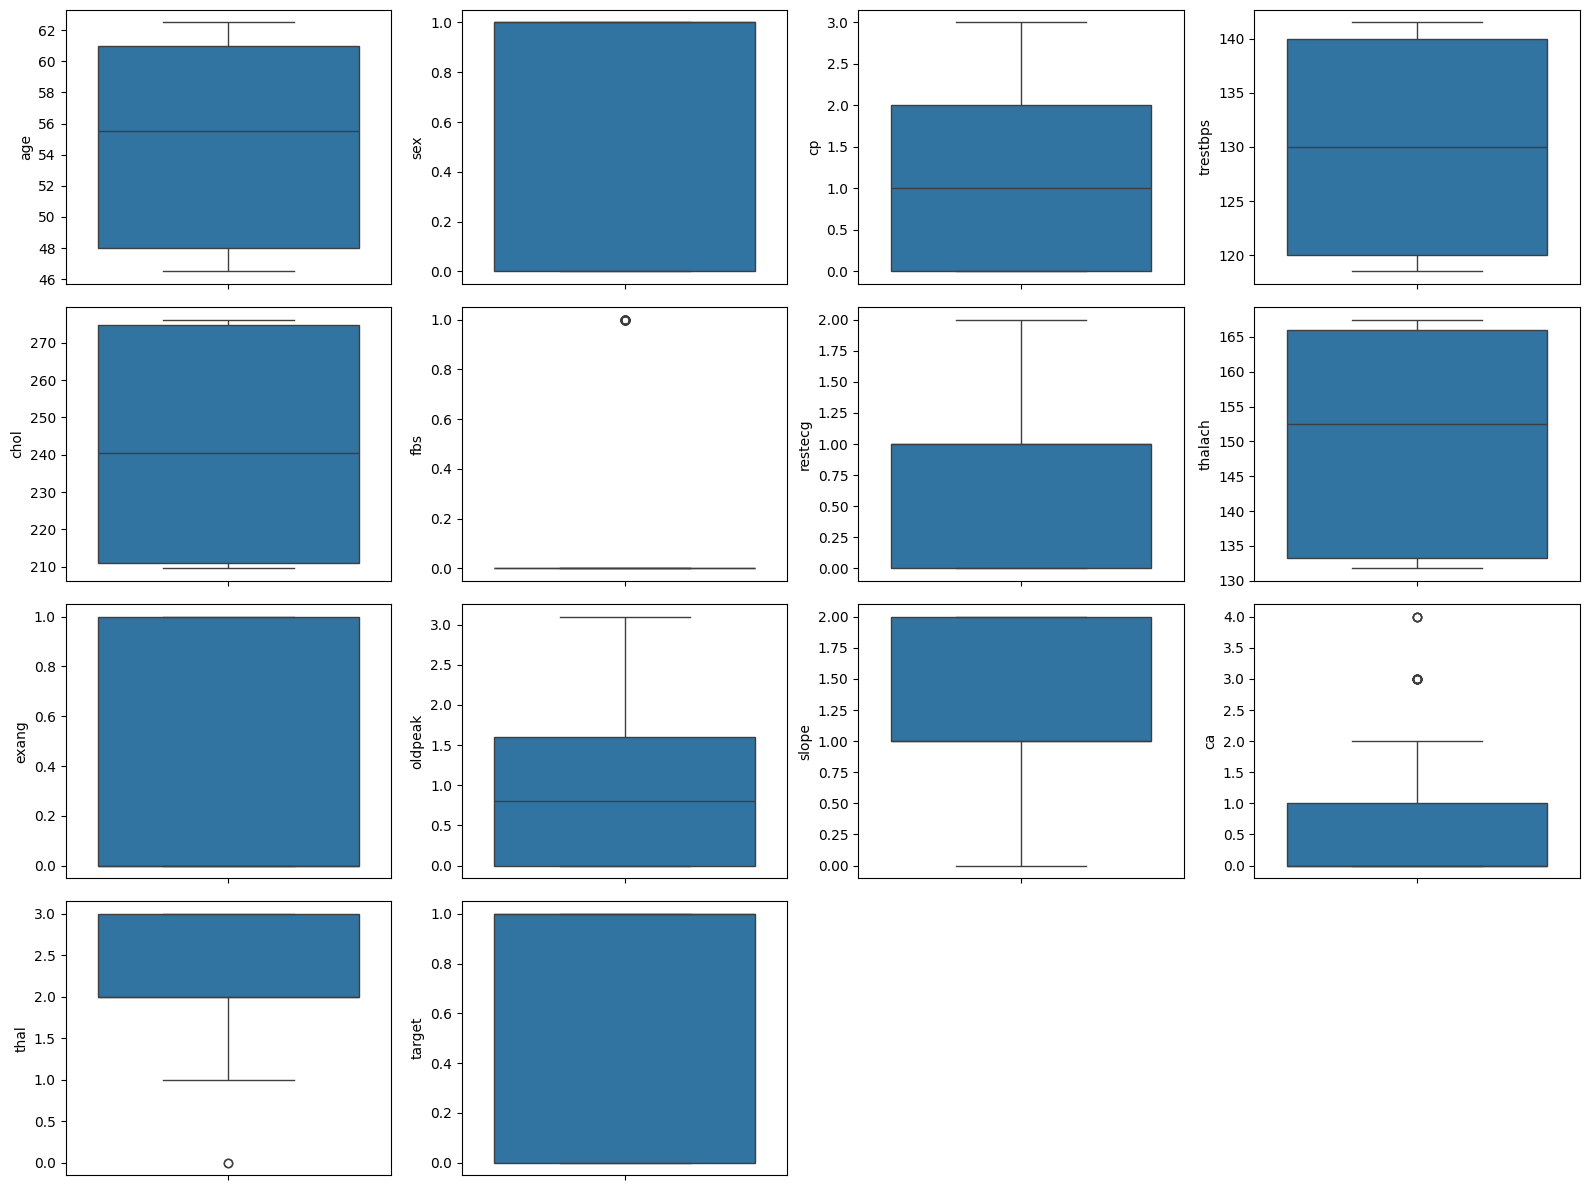

In [98]:
# After outlier handling
plt.figure(figsize=(16,12))
for i in range(len(num_cols)):
  plt.subplot(4, 4, i+1)
  sns.boxplot(df_heart_disease[num_cols[i]])
plt.tight_layout()
plt.show()

In [99]:
# cols to be one-hot encoded are:
ohe_cols = ['cp', 'restecg', 'thal']

# binary feature cols are already encoded -> 'sex', 'fbs' and 'exang'

In [100]:
# Initialize encoder
ohe_obj = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Encode
encoded = ohe_obj.fit_transform(df_heart_disease[ohe_cols])

# Create DataFrame with encoded column names
encoded_df = pd.DataFrame(
    encoded,
    columns = ohe_obj.get_feature_names_out(ohe_cols),
    index=df_heart_disease.index
)

# Drop original columns and concatenate encoded columns
df_heart_disease = pd.concat([df_heart_disease.drop(columns = ohe_cols), encoded_df], axis=1)

df_heart_disease.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,...,cp_1,cp_2,cp_3,restecg_0,restecg_1,restecg_2,thal_0,thal_1,thal_2,thal_3
0,52.0,1,125.0,212.00,0,167.50,0,1.0,2,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,53.0,1,140.0,209.50,1,155.00,1,3.1,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,62.5,1,141.5,209.50,0,131.75,1,2.6,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,61.0,1,141.5,209.50,0,161.00,0,0.0,2,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,62.0,0,138.0,276.25,1,131.75,0,1.9,1,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [101]:
# cols to be scaled are:
scale_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [102]:
# Initialize scaler
scaler = StandardScaler()

# Scale the selected columns
df_heart_disease[scale_cols] = scaler.fit_transform(df_heart_disease[scale_cols])

# Display the first few rows
df_heart_disease.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,...,cp_1,cp_2,cp_3,restecg_0,restecg_1,restecg_2,thal_0,thal_1,thal_2,thal_3
0,-0.445906,1,-0.551942,-1.132767,0,1.181638,0,0.009726,2,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,-0.282875,1,1.081705,-1.226009,1,0.290259,1,2.065838,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.265920,1,1.245070,-1.226009,0,-1.367706,1,1.576287,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,1.021373,1,1.245070,-1.226009,0,0.718121,0,-0.969375,2,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,1.184404,0,0.863885,1.263553,1,-1.367706,0,0.890917,1,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


#Train-Test Split

In [104]:
# Features and target
X = df_heart_disease.drop(columns='target')
y = df_heart_disease['target']    # target_col = 'target'

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (241, 21)
X_test : (61, 21)
y_train: (241,)
y_test : (61,)
